In [1]:
from langgraph.graph import StateGraph, START, END 
from typing import TypedDict

In [2]:
# State
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    
    strike_rate: float
    balls_per_boundary: float
    boundary_percentage: float
    summary: str

In [3]:
# Function Calculate Strike Rate
def calculate_SR(state: BatsmanState) -> BatsmanState:
    strike_rate = (state["runs"] / state["balls"]) * 100
    
    return {"strike_rate": strike_rate}

In [4]:
# function Calculate Balls Per Boundary
def calculate_BPB(state: BatsmanState) -> BatsmanState:
    balls_per_boundary = state["balls"] / (state["fours"] + state["sixes"])
    
    return {"balls_per_boundary": balls_per_boundary}

In [5]:
# function Calculate Boundary Percentage
def calculate_BP(state: BatsmanState) -> BatsmanState:
    boundary_percentage = (((state["fours"] * 4) + (state["sixes"] * 6)) / state["runs"]) * 100
    
    return {"boundary_percentage": boundary_percentage}

In [10]:
# function Summary
def summary(state: BatsmanState) -> BatsmanState:
    summary = f"""
    Strike Rate- {state["strike_rate"]} \n 
    Balls Per Boundary- {state["balls_per_boundary"]} \n
    Boundary Percentage- {state["boundary_percentage"]}
    """

    return {"summary": summary}

In [11]:
# Graph
graph = StateGraph(BatsmanState)

# Nodes
graph.add_node("Calculate_Strike_Rate", calculate_SR)
graph.add_node("Calculate_Balls_Per_Boundary", calculate_BPB)
graph.add_node("Calculate_Boundary_Percentage", calculate_BP)
graph.add_node("Summary", summary)

# Edges
graph.add_edge(START, "Calculate_Strike_Rate")
graph.add_edge(START, "Calculate_Balls_Per_Boundary")
graph.add_edge(START, "Calculate_Boundary_Percentage")

graph.add_edge("Calculate_Strike_Rate", "Summary")
graph.add_edge("Calculate_Balls_Per_Boundary", "Summary")
graph.add_edge("Calculate_Boundary_Percentage", "Summary")

graph.add_edge("Summary", END)

# Compile
workflow = graph.compile()


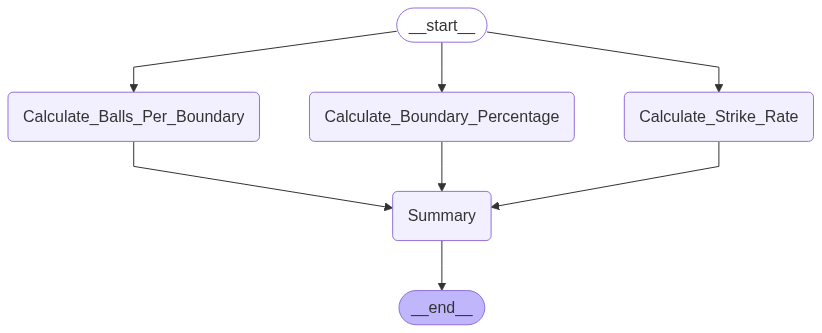

In [12]:
workflow

In [14]:
# Execute
initial_state = {
    "runs": 100,
    "balls": 50,
    "fours": 6,
    "sixes": 4
}

final_state = workflow.invoke(initial_state)

final_state

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'strike_rate': 200.0,
 'balls_per_boundary': 5.0,
 'boundary_percentage': 48.0,
 'summary': '\n    Strike Rate- 200.0 \n \n    Balls Per Boundary- 5.0 \n\n    Boundary Percentage- 48.0\n    '}